In [1]:
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import helper

In [2]:
df = helper.prepare_data()

In [3]:
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values
X,y = SMOTE(random_state=42).fit_resample(X,y)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

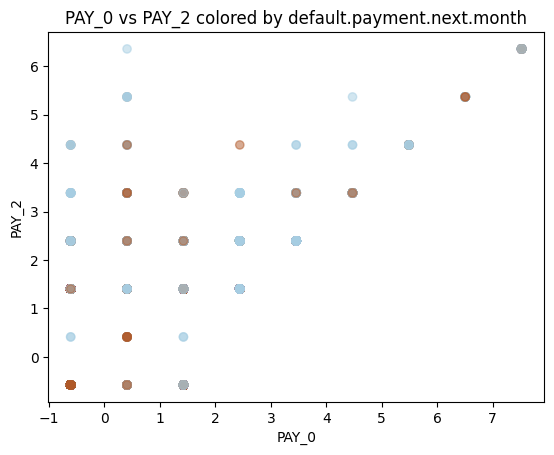

In [16]:
# scatter plot only first two features
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='Paired_r', alpha=0.5)
plt.xlabel('PAY_0')
plt.ylabel('PAY_2')
plt.title('PAY_0 vs PAY_2 colored by default.payment.next.month')
plt.show()

Accuracy: 0.7238991968983661
Confusion Matrix:


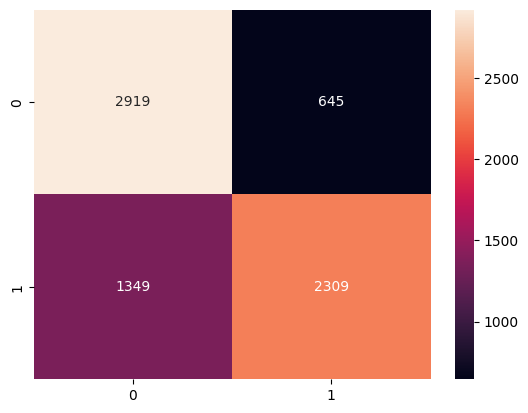

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.82      0.75      3564
           1       0.78      0.63      0.70      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.73      0.72      7222
weighted avg       0.73      0.72      0.72      7222



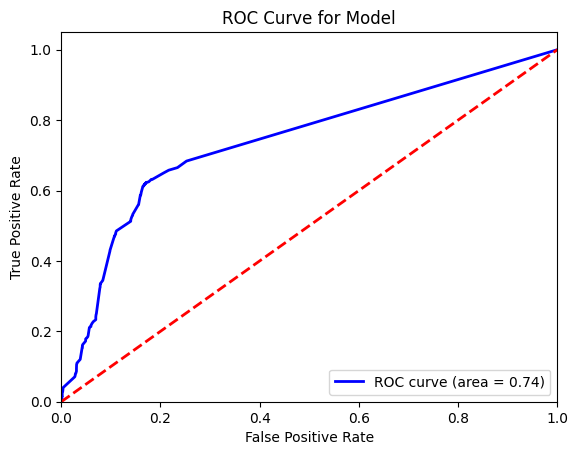

In [19]:
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
y_pred_proba = svm_clf.decision_function(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)

In [13]:
print(y_pred_proba[:5])
print(y_pred[:5])

[ 1.00039031 -0.9996253  -0.9996253  -0.99970837 -0.9996253 ]
[1 0 0 0 0]


Accuracy: 0.7244530600941568
Confusion Matrix:


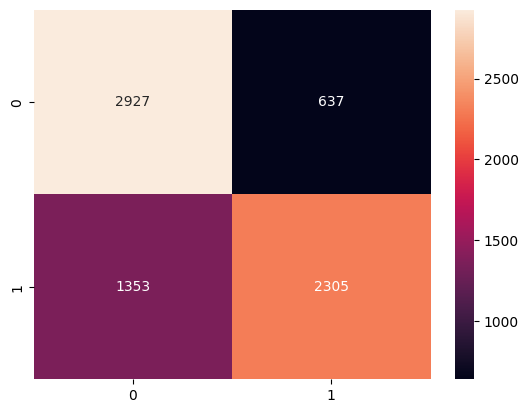

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.82      0.75      3564
           1       0.78      0.63      0.70      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.73      0.72      7222
weighted avg       0.73      0.72      0.72      7222



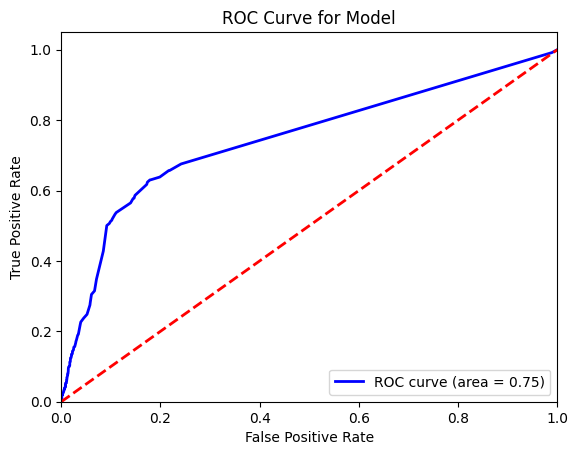

In [22]:
svm_clf = SVC(kernel='poly', degree=2, random_state=42)
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
y_pred_proba = svm_clf.decision_function(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)

In [8]:
class SVM_Non_Linear_Scratch:
    def __init__(self, kernel='poly', C=1, degree=2, const=1, sigma=0.1,
                 iterations=1000, learning_rate=0.001, batch_size=256,
                 log_interval=100, tol=1e-5, cache_size=512):
        self.X = None
        self.y = None
        self.alpha = None
        self.ones = None
        self.b = 0
        self.C = C
        self.iterations = iterations
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.log_interval = log_interval
        self.tol = tol
        self.cache_size = cache_size  # max columns to cache

        if kernel == 'poly':
            self.kernel = self.polynomial_kernel
            self.degree = degree
            self.const = const
        elif kernel == 'rbf':
            self.kernel = self.gaussian_kernel
            self.sigma = sigma

        # Internal state for RBF norm precomputation
        self._X_sq_norms = None
        # Kernel column cache: maps column index -> kernel column vector
        self._kernel_cache = {}
        self._cache_order = []  # LRU order tracking

    # ----------------------------------------------------------------
    # Kernel functions — optimized to avoid 3D broadcasting
    # ----------------------------------------------------------------
    def polynomial_kernel(self, X, Z):
        # K(X, Z) = (c + X.Z^T)^degree
        return (self.const + X.dot(Z.T)) ** self.degree

    def gaussian_kernel(self, X, Z):
        """
        K(X, Z) = exp( -||x-z||^2 / σ^2 )

        Original used X[:, np.newaxis] - Z[np.newaxis, :] which creates a
        3D tensor of shape (n1, n2, d) — extremely memory-hungry and slow.

        Optimized: ||x-z||^2 = ||x||^2 + ||z||^2 - 2*x.z^T
        This uses only 2D operations.
        """
        # ||X||^2 as column vector (n1, 1)
        X_sq = np.sum(X ** 2, axis=1, keepdims=True)
        # ||Z||^2 as row vector (1, n2)
        Z_sq = np.sum(Z ** 2, axis=1, keepdims=True).T
        # Squared distances: (n1, n2)
        sq_dists = X_sq + Z_sq - 2.0 * X.dot(Z.T)
        # Numerical safety: clamp negatives from floating point error
        np.maximum(sq_dists, 0.0, out=sq_dists)
        return np.exp(-sq_dists / (self.sigma ** 2))

    # ----------------------------------------------------------------
    # Kernel cache helpers — avoid recomputing the same kernel columns
    # ----------------------------------------------------------------
    def _get_kernel_columns(self, indices):
        """
        Return kernel matrix K(X_train, X_train[indices]) of shape (n, len(indices)).
        Uses column cache to avoid redundant computation. Uncached columns
        are computed in a single batched call.
        """
        n = self.X.shape[0]
        result = np.empty((n, len(indices)), dtype=np.float64)
        uncached_mask = []
        uncached_orig_pos = []

        for pos, idx in enumerate(indices):
            if idx in self._kernel_cache:
                result[:, pos] = self._kernel_cache[idx]
                # Move to end of LRU list
                self._cache_order.remove(idx)
                self._cache_order.append(idx)
            else:
                uncached_mask.append(idx)
                uncached_orig_pos.append(pos)

        # Batch-compute all uncached columns at once
        if uncached_mask:
            uncached_indices = np.array(uncached_mask)
            # Compute K(X_train, X_train[uncached]) in chunks to limit memory
            K_new = np.empty((n, len(uncached_indices)), dtype=np.float64)
            chunk = max(self.batch_size, 512)
            for start in range(0, n, chunk):
                end = min(start + chunk, n)
                K_new[start:end, :] = self.kernel(self.X[start:end], self.X[uncached_indices])

            for i, (idx, pos) in enumerate(zip(uncached_mask, uncached_orig_pos)):
                col = K_new[:, i]
                result[:, pos] = col
                # Add to cache with LRU eviction
                if len(self._kernel_cache) >= self.cache_size:
                    evict = self._cache_order.pop(0)
                    del self._kernel_cache[evict]
                self._kernel_cache[idx] = col
                self._cache_order.append(idx)

        return result

    # ----------------------------------------------------------------
    # Decision function — chunked to limit memory
    # ----------------------------------------------------------------
    def decision_function(self, X):
        # ŷ = ∑( αi*yi * K(xi, x) ) + b
        # Only use support vectors (α > 0) for prediction — huge speedup
        sv_mask = self.alpha > self.tol
        sv_X = self.X[sv_mask]
        sv_alpha = self.alpha[sv_mask]
        sv_y = self.y[sv_mask]
        coeff = sv_alpha * sv_y  # (n_sv,)

        m = X.shape[0]
        result = np.zeros(m)
        chunk = self.batch_size
        for start in range(0, len(coeff), chunk):
            end = min(start + chunk, len(coeff))
            K_chunk = self.kernel(sv_X[start:end], X)  # (chunk, m)
            result += coeff[start:end].dot(K_chunk)
        return result + self.b

    # ----------------------------------------------------------------
    # Training — mini-batch dual ascent with key optimizations
    # ----------------------------------------------------------------
    def fit(self, X, y):
        y = np.where(y <= 0, -1, 1)
        self.X = X
        self.y = y
        n = X.shape[0]
        self.alpha = np.random.random(n) * 0.01  # small init for stability
        self.b = 0
        losses = []

        # Reset kernel cache for new fit
        self._kernel_cache = {}
        self._cache_order = []

        for iteration in range(self.iterations):
            # Sample a mini-batch of indices
            batch_size = min(self.batch_size, n)
            batch_idx = np.random.choice(n, size=batch_size, replace=False)

            # ============================================================
            # KEY OPTIMIZATION: Use kernel cache for batch columns
            # Instead of computing K(X_batch, X_all) from scratch each time,
            # retrieve cached kernel columns where available.
            #
            # K_cols shape: (n, batch_size) — full columns for batch indices
            # We need kernel_batch = K_cols[batch_idx, :] for the gradient,
            # but the dual SVM gradient is:
            #   ∇αi = 1 - ∑j αj*yj*yi*K(xi,xj)   for i in batch
            #
            # The sum ∑j runs over ALL j, so we need K(X_batch, X_all).
            # With caching: retrieve K[:, batch_idx] then index rows we need.
            # Without caching (fallback): compute K(X_batch, X_all) directly.
            # ============================================================

            # For moderate n (< 30k), column caching is effective.
            # For each batch index, get/cache the full kernel column.
            if n <= 30000:
                K_cols = self._get_kernel_columns(batch_idx)  # (n, batch_size)
                # kernel_batch[i, j] = K(X[batch_idx[i]], X[j]) — we need (batch_size, n)
                # K_cols is (n, batch_size), so transpose then we have (batch_size, n)
                # But K_cols[:, i] = K(X_all, X[batch_idx[i]])
                # We need K(X[batch_idx], X_all) = K_cols.T (by kernel symmetry)
                kernel_batch = K_cols.T  # (batch_size, n)
            else:
                # Fallback: direct computation for very large datasets
                kernel_batch = self.kernel(X[batch_idx], X)

            y_batch = y[batch_idx]

            # (yi*yj) * K(xi, xj) for batch rows vs all columns
            # kernel_mat_batch: (batch_size, n)
            kernel_mat_batch = (y_batch[:, np.newaxis] * y[np.newaxis, :]) * kernel_batch

            # gradient for batch indices: 1 – kernel_mat_batch.dot(alpha)
            gradient = np.ones(batch_size) - kernel_mat_batch.dot(self.alpha)

            # α = α + η * gradient (only update batch indices)
            self.alpha[batch_idx] += self.learning_rate * gradient
            # 0 < α < C — clip in-place
            np.clip(self.alpha, 0, self.C, out=self.alpha)

            # Invalidate cache for modified indices (their kernel columns
            # haven't changed — kernel depends on X not alpha — so no
            # invalidation needed. Cache remains valid.)

            # Log loss periodically
            if (iteration + 1) % self.log_interval == 0 or iteration == 0:
                # Approximate dual objective using batch samples only
                # to avoid expensive full kernel computation
                K_sample = kernel_batch[:, batch_idx]  # (batch_size, batch_size) — free, already computed
                alpha_s = self.alpha[batch_idx]
                y_s = y[batch_idx]
                scale = n / batch_size
                loss = scale * np.sum(alpha_s) - 0.5 * scale**2 * np.sum(
                    np.outer(alpha_s, alpha_s) * np.outer(y_s, y_s) * K_sample
                )
                losses.append(loss)
                print(f"Iteration {iteration + 1}/{self.iterations} | Approx Loss: {loss:.4f}")

        # ============================================================
        # Bias computation — only use support vectors
        # b = avg over SV { yi – ∑j( αj*yj * K(xj, xi) ) }
        # ============================================================
        sv_mask = (self.alpha > self.tol) & (self.alpha < self.C - self.tol)
        index = np.where(sv_mask)[0]

        if len(index) == 0:
            # Fallback: use all α > 0
            index = np.where(self.alpha > self.tol)[0]

        if len(index) == 0:
            self.b = 0.0
        else:
            # Only need contributions from support vectors (α > tol)
            active_mask = self.alpha > self.tol
            active_idx = np.where(active_mask)[0]
            active_X = X[active_idx]
            active_alpha = self.alpha[active_idx]
            active_y = y[active_idx]
            coeff = active_alpha * active_y  # (n_active,)

            # Compute ∑j(αj*yj*K(xj, xi)) for each i in index
            # K(active_X, X[index]) -> (n_active, len(index))
            b_vals = np.zeros(len(index))
            chunk = self.batch_size
            for start in range(0, len(active_idx), chunk):
                end = min(start + chunk, len(active_idx))
                K_chunk = self.kernel(active_X[start:end], X[index])
                b_vals += coeff[start:end].dot(K_chunk)
            b_vals = y[index] - b_vals
            self.b = np.mean(b_vals)

        return self.alpha, self.b, losses

    def predict(self, X):
        prediction = self.decision_function(X)
        label_signs = np.sign(prediction)
        result = np.where(label_signs <= -1, 0, 1)
        return result

Iteration 1/1000 | Approx Loss: -8583866.5449
Iteration 100/1000 | Approx Loss: -508229.5209
Iteration 200/1000 | Approx Loss: -267223.6974
Iteration 300/1000 | Approx Loss: -527410.2345
Iteration 400/1000 | Approx Loss: -388788.4178
Iteration 500/1000 | Approx Loss: -700603.0472
Iteration 600/1000 | Approx Loss: -287656.5721
Iteration 700/1000 | Approx Loss: -258615.0753
Iteration 800/1000 | Approx Loss: -207640.4859
Iteration 900/1000 | Approx Loss: -141220.5596
Iteration 1000/1000 | Approx Loss: -143786.4353
Accuracy: 0.6752977014677375
Confusion Matrix:


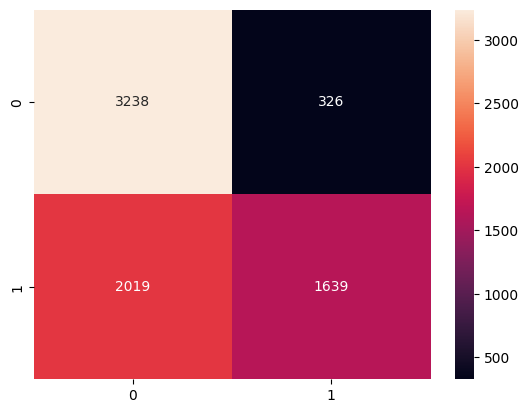

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.91      0.73      3564
           1       0.83      0.45      0.58      3658

    accuracy                           0.68      7222
   macro avg       0.73      0.68      0.66      7222
weighted avg       0.73      0.68      0.66      7222



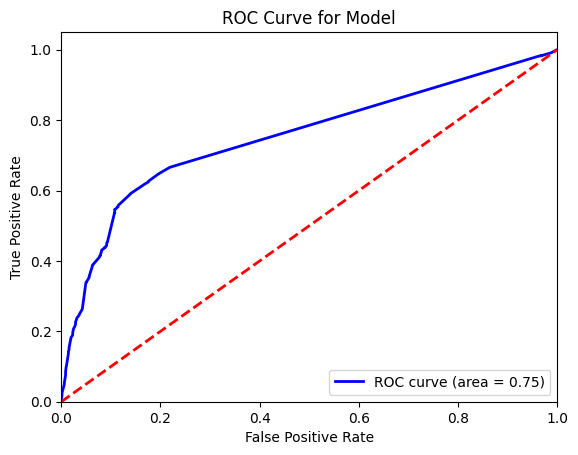

In [5]:
svm_scratch = SVM_Non_Linear_Scratch(kernel='rbf', C=1, sigma=0.1, iterations=1000, learning_rate=0.001, batch_size=256, log_interval=100)
svm_scratch.fit(X_train, y_train)
y_pred_scratch_proba = svm_scratch.decision_function(X_test)
y_pred_scratch = np.where(np.sign(y_pred_scratch_proba) <= -1, 0, 1)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_scratch_proba)

Iteration 1/1000 | Approx Loss: -852677543.5253
Iteration 100/1000 | Approx Loss: -40344787.3074
Iteration 200/1000 | Approx Loss: -164376529.1516
Iteration 300/1000 | Approx Loss: -98122830.0438
Iteration 400/1000 | Approx Loss: -20690242.0648
Iteration 500/1000 | Approx Loss: -24982974.8215
Iteration 600/1000 | Approx Loss: -154807026.7137
Iteration 700/1000 | Approx Loss: -34069214.8200
Iteration 800/1000 | Approx Loss: -38357138.2551
Iteration 900/1000 | Approx Loss: -20530092.6305
Iteration 1000/1000 | Approx Loss: -4810824.3623
Accuracy: 0.6762669620603711
Confusion Matrix:


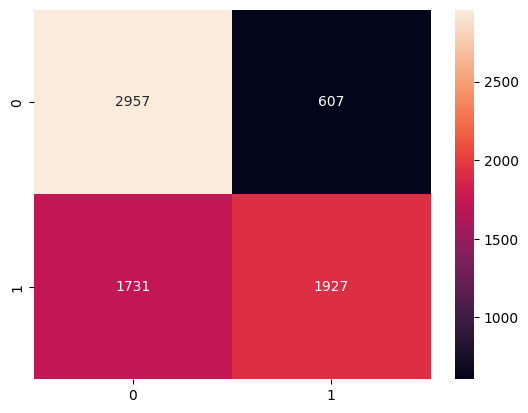

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.83      0.72      3564
           1       0.76      0.53      0.62      3658

    accuracy                           0.68      7222
   macro avg       0.70      0.68      0.67      7222
weighted avg       0.70      0.68      0.67      7222



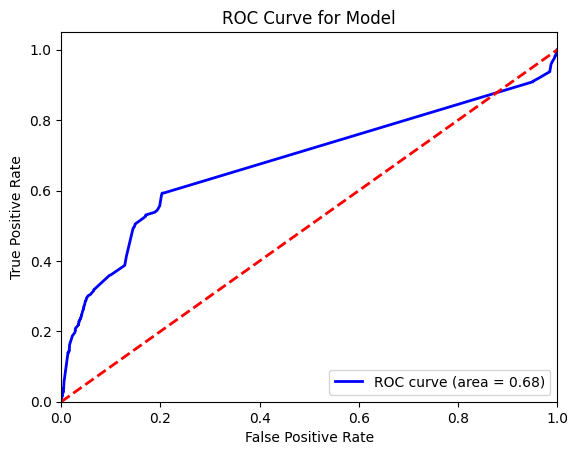

In [6]:
svm_scratch_poly = SVM_Non_Linear_Scratch(kernel='poly', degree=2, const=1, C=1, iterations=1000, learning_rate=0.001, batch_size=256, log_interval=100)
svm_scratch_poly.fit(X_train, y_train)
y_pred_scratch_poly_proba = svm_scratch_poly.decision_function(X_test)
y_pred_scratch_poly = np.where(np.sign(y_pred_scratch_poly_proba) <= -1, 0, 1)
helper.evaluate_model(y_test, y_pred_scratch_poly)
helper.plot_roc_curve(y_test, y_pred_scratch_poly_proba)

## All features

In [3]:
X = df.drop(['default.payment.next.month'], axis=1).values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X,y = SMOTE(random_state=42).fit_resample(X,y)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Accuracy: 0.7312378842425921
Confusion Matrix:


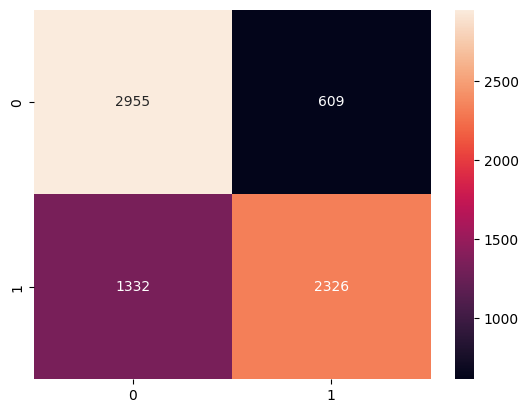

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.83      0.75      3564
           1       0.79      0.64      0.71      3658

    accuracy                           0.73      7222
   macro avg       0.74      0.73      0.73      7222
weighted avg       0.74      0.73      0.73      7222



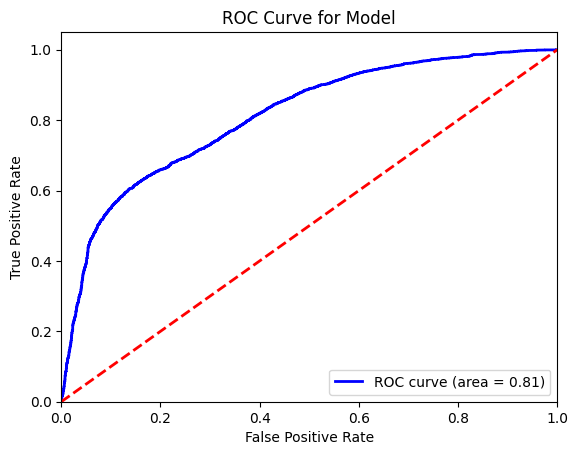

In [4]:
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
y_pred_proba = svm_clf.decision_function(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)

Iteration 1/1000 | Approx Loss: -583008.9483
Iteration 100/1000 | Approx Loss: -539757.5069
Iteration 200/1000 | Approx Loss: -530592.7082
Iteration 300/1000 | Approx Loss: -602942.5617
Iteration 400/1000 | Approx Loss: -531921.8517
Iteration 500/1000 | Approx Loss: -584976.6675
Iteration 600/1000 | Approx Loss: -485645.5894
Iteration 700/1000 | Approx Loss: -566773.8417
Iteration 800/1000 | Approx Loss: -539535.1361
Iteration 900/1000 | Approx Loss: -561706.0076
Iteration 1000/1000 | Approx Loss: -569516.1216
Accuracy: 0.6636665743561341
Confusion Matrix:


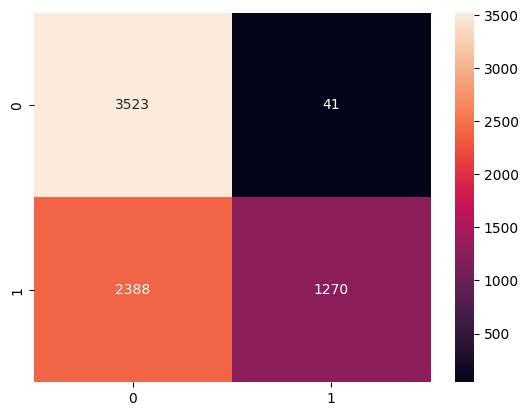

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.99      0.74      3564
           1       0.97      0.35      0.51      3658

    accuracy                           0.66      7222
   macro avg       0.78      0.67      0.63      7222
weighted avg       0.78      0.66      0.63      7222



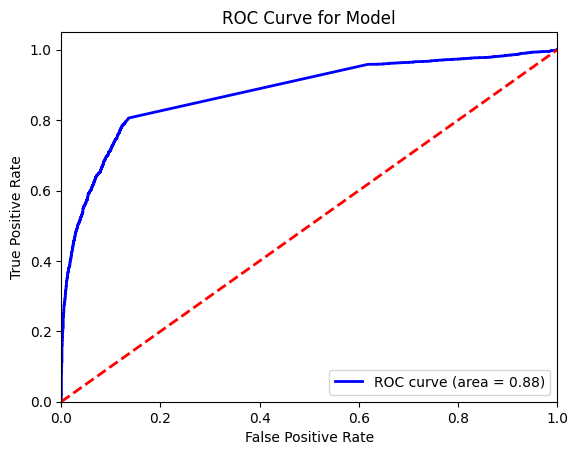

In [7]:
svm_scratch = SVM_Non_Linear_Scratch(kernel='rbf', C=1, sigma=0.1, iterations=1000, learning_rate=0.001, batch_size=256, log_interval=100)
svm_scratch.fit(X_train, y_train)
y_pred_scratch_proba = svm_scratch.decision_function(X_test)
y_pred_scratch = np.where(np.sign(y_pred_scratch_proba) <= -1, 0, 1)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_scratch_proba)

Iteration 1/1000 | Approx Loss: 102.3815
Iteration 100/1000 | Approx Loss: 106.1193
Iteration 200/1000 | Approx Loss: 108.7355
Iteration 300/1000 | Approx Loss: 109.7060
Iteration 400/1000 | Approx Loss: 109.0661
Iteration 500/1000 | Approx Loss: 101.4111
Iteration 600/1000 | Approx Loss: 94.9956
Iteration 700/1000 | Approx Loss: 85.7025
Iteration 800/1000 | Approx Loss: 74.1164
Iteration 900/1000 | Approx Loss: 64.1621
Iteration 1000/1000 | Approx Loss: 39.3690
Accuracy: 0.6452506230960953
Confusion Matrix:


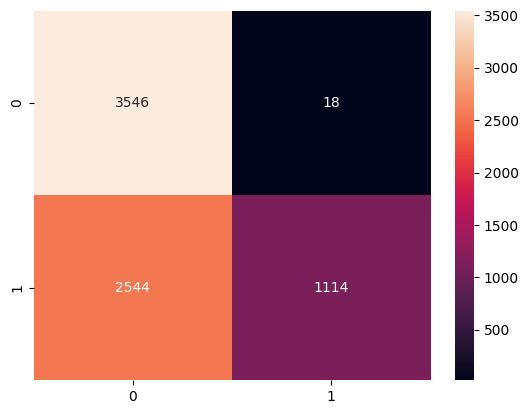

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.99      0.73      3564
           1       0.98      0.30      0.47      3658

    accuracy                           0.65      7222
   macro avg       0.78      0.65      0.60      7222
weighted avg       0.79      0.65      0.60      7222



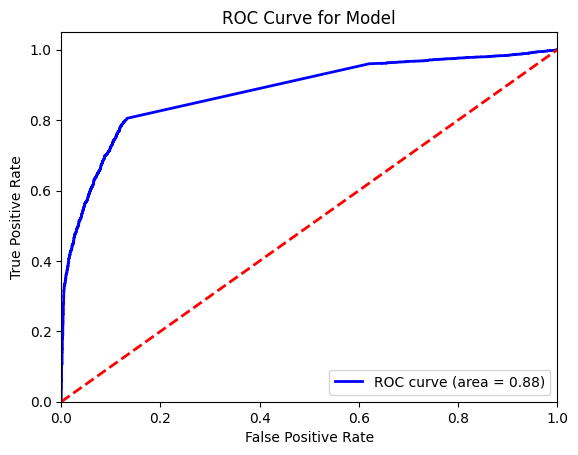

In [9]:
svm_scratch = SVM_Non_Linear_Scratch(kernel='rbf', C=1, sigma=0.1, iterations=1000, learning_rate=0.001, batch_size=256, log_interval=100)
svm_scratch.fit(X_train, y_train)
y_pred_scratch_proba = svm_scratch.decision_function(X_test)
y_pred_scratch = np.where(np.sign(y_pred_scratch_proba) <= -1, 0, 1)
helper.evaluate_model(y_test, y_pred_scratch)
helper.plot_roc_curve(y_test, y_pred_scratch_proba)

Accuracy: 0.719883688728884
Confusion Matrix:


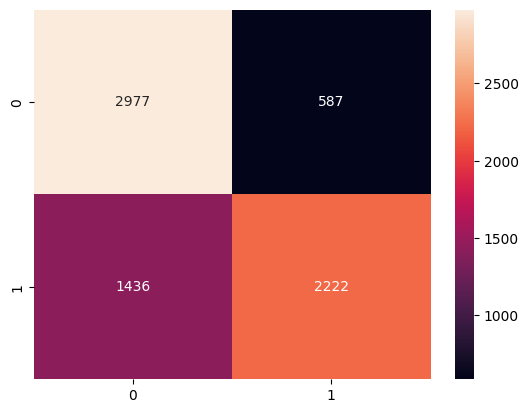

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.84      0.75      3564
           1       0.79      0.61      0.69      3658

    accuracy                           0.72      7222
   macro avg       0.73      0.72      0.72      7222
weighted avg       0.73      0.72      0.72      7222



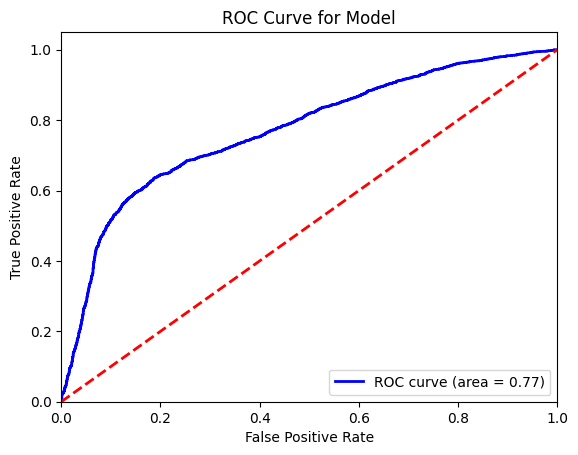

In [10]:
svm_clf = SVC(kernel='poly', degree=2, random_state=42)
svm_clf.fit(X_train, y_train)
y_pred = svm_clf.predict(X_test)
y_pred_proba = svm_clf.decision_function(X_test)
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba)

Iteration 1/1000 | Approx Loss: -343593078.5780
Iteration 100/1000 | Approx Loss: -3719164425.3752
Iteration 200/1000 | Approx Loss: -6008015964.8001
Iteration 300/1000 | Approx Loss: -2633537621.4378
Iteration 400/1000 | Approx Loss: -1372395266.3367
Iteration 500/1000 | Approx Loss: -2038265121.4971
Iteration 600/1000 | Approx Loss: -2514225588.6866
Iteration 700/1000 | Approx Loss: -1549563714.2047
Iteration 800/1000 | Approx Loss: -3084500249.9032
Iteration 900/1000 | Approx Loss: -2535454208.1852
Iteration 1000/1000 | Approx Loss: -2148827512.3554
Accuracy: 0.6574356134034893
Confusion Matrix:


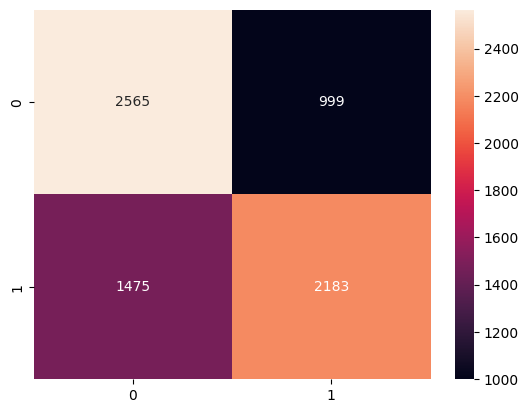

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.72      0.67      3564
           1       0.69      0.60      0.64      3658

    accuracy                           0.66      7222
   macro avg       0.66      0.66      0.66      7222
weighted avg       0.66      0.66      0.66      7222



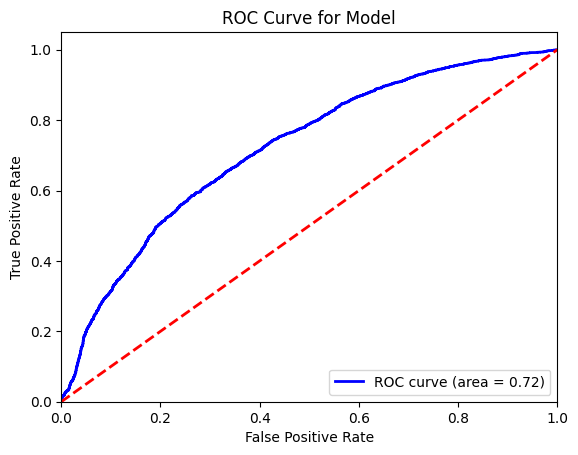

In [11]:
svm_scratch_poly = SVM_Non_Linear_Scratch(kernel='poly', degree=2, const=1, C=1, iterations=1000, learning_rate=0.001, batch_size=256, log_interval=100)
svm_scratch_poly.fit(X_train, y_train)
y_pred_scratch_poly_proba = svm_scratch_poly.decision_function(X_test)
y_pred_scratch_poly = np.where(np.sign(y_pred_scratch_poly_proba) <= -1, 0, 1)
helper.evaluate_model(y_test, y_pred_scratch_poly)
helper.plot_roc_curve(y_test, y_pred_scratch_poly_proba)